In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/shimnet_workshop

Mounted at /content/drive
/content/drive/MyDrive/shimnet_workshop


In [3]:
ls

calibration_loop/              Readme.md
configs/                       requirements-colab.txt
data/                          requirements-cpu.txt
display_spectra_Cresol_Red.py  requirements-gpu.txt
display_spectra.py             requirements-gui.txt
Dockerfile                     sample_data/
download_files.py              SCRF_extraction/
extract_scrf_from_fids.py      shimnet/
INPUT/                         src/
LICENSE                        train.py
OPTI_INPUT_SPECTRA/            weights/
predict-gui.py                 Workshop_Colab_notebooks/
predict.py


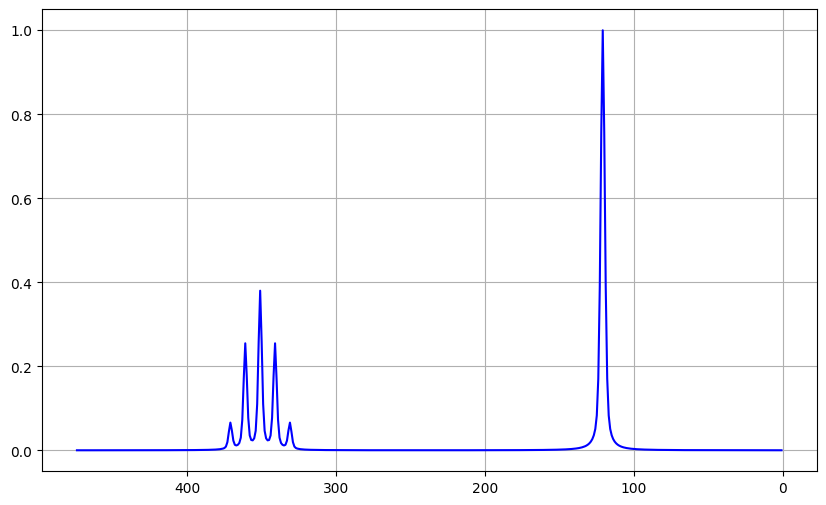

In [7]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import os

folder_path = "/content/drive/MyDrive/shimnet_workshop/data"
file_name = "spectrum_singlet_and_multiplet2.txt"
file_path = os.path.join(folder_path, file_name)

df = pd.read_csv(file_path, header=None)
df.columns = ["intensity"]
df["index"] = range(1, len(df) + 1)

plt.figure(figsize=(10, 6))
plt.plot(df["index"], df["intensity"], color="blue")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()



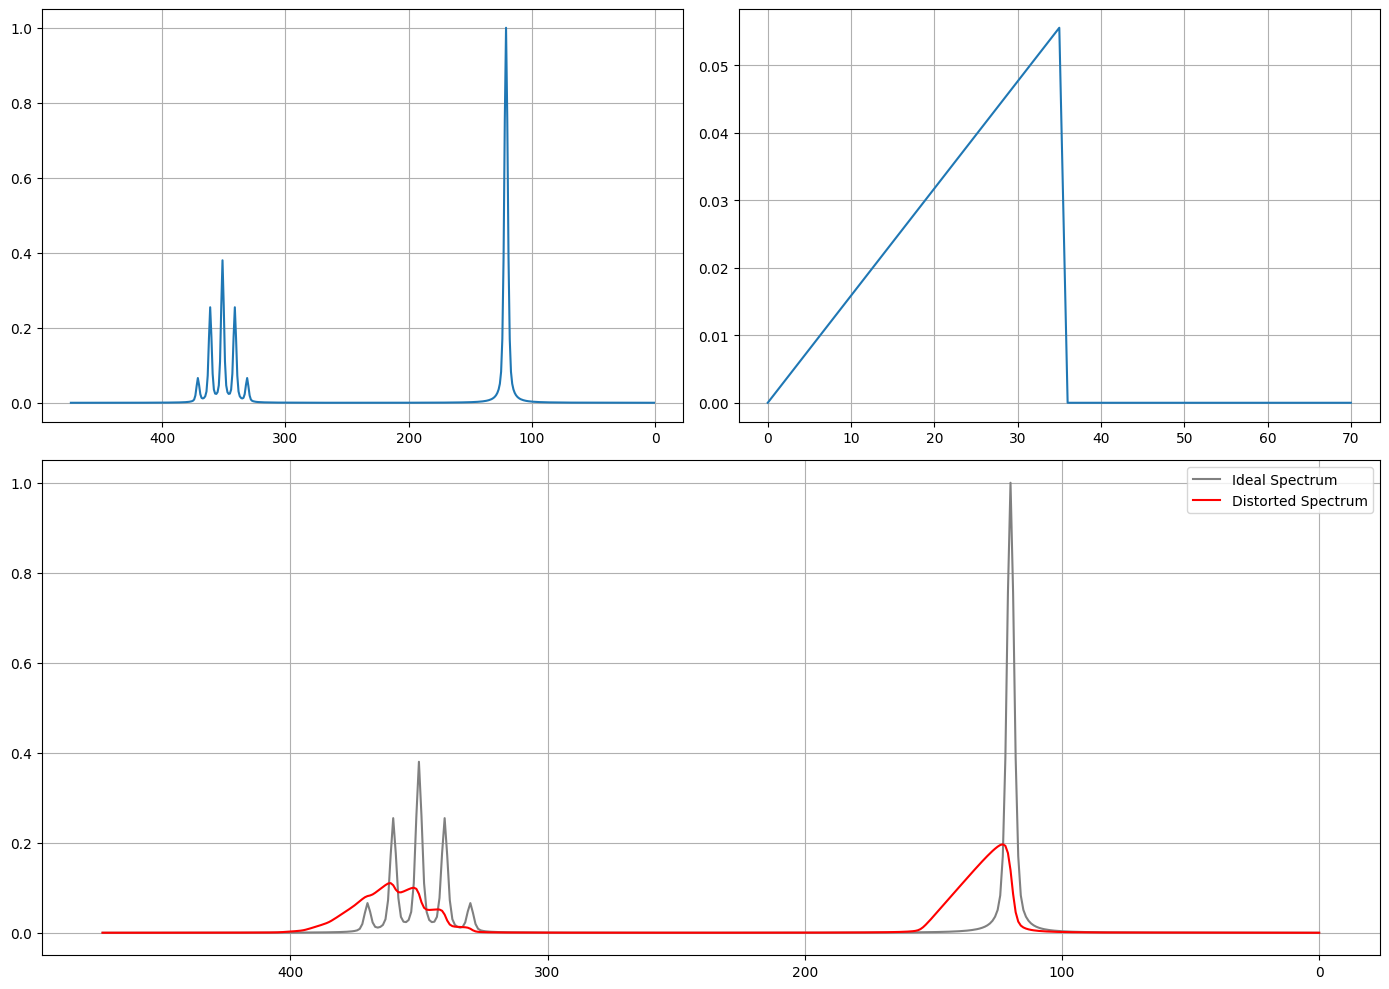

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import os


file_path = "/content/drive/MyDrive/shimnet_workshop/data/spectrum_singlet_and_multiplet2.txt"
df = pd.read_csv(file_path, header=None, names=["intensity"])
df["index"] = range(1, len(df) + 1)
original_spectrum = torch.tensor(df["intensity"].values, dtype=torch.float32).view(1,1,-1)


response_function_length = 71
resp = torch.cat([torch.arange(response_function_length//2+1).float(), torch.zeros(response_function_length//2)])

# halfwidth = 7 #change from 1 to 15 only total values
# resp = torch.arange(1, 2*halfwidth+1, dtype=torch.float32)
# resp = torch.cat([torch.zeros(halfwidth), resp, torch.zeros(halfwidth-1)])
resp /= resp.sum()


distorted = F.conv1d(original_spectrum, resp.view(1,1,-1), padding=len(resp)//2)


fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

ax1 = fig.add_subplot(gs[0,0])
ax1.plot(df["index"], df["intensity"]); ax1.invert_xaxis(); ax1.grid(True)

ax2 = fig.add_subplot(gs[0,1])
ax2.plot(resp); ax2.grid(True)

ax3 = fig.add_subplot(gs[1,:])
ax3.plot(original_spectrum[0,0], label="Ideal Spectrum",  c="0.5")
ax3.plot(distorted[0,0].detach(), label="Distorted Spectrum", color="red")
ax3.invert_xaxis()
ax3.legend()
ax3.grid(True)

plt.tight_layout(); plt.show()





## Fitting

In [36]:
def fit_kernel(base, target, kernel_size, steps=12000, verbose=False):

    best_kernel = None
    best_loss = float('inf')

    kernel = torch.ones((1,1,kernel_size), dtype=base.dtype)
    kernel /= kernel_size
    kernel.requires_grad = True

    optimizer = torch.optim.Adam([kernel])

    for epoch in range(steps):
        spe_est = torch.conv1d(base, kernel, padding='same')
        loss = torch.mean(abs(target - spe_est)**2) #torch.nn.functional.mse_loss(spe_est, target)

        if loss < best_loss:
            best_loss = loss
            best_kernel = kernel.detach().clone()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if verbose and (epoch+1) % 200 == 0:
            print(epoch, loss.item())
    return best_kernel, best_loss.item()

### Fitting on clean spectra

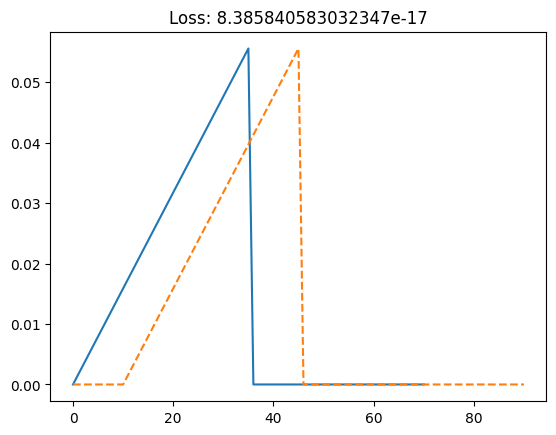

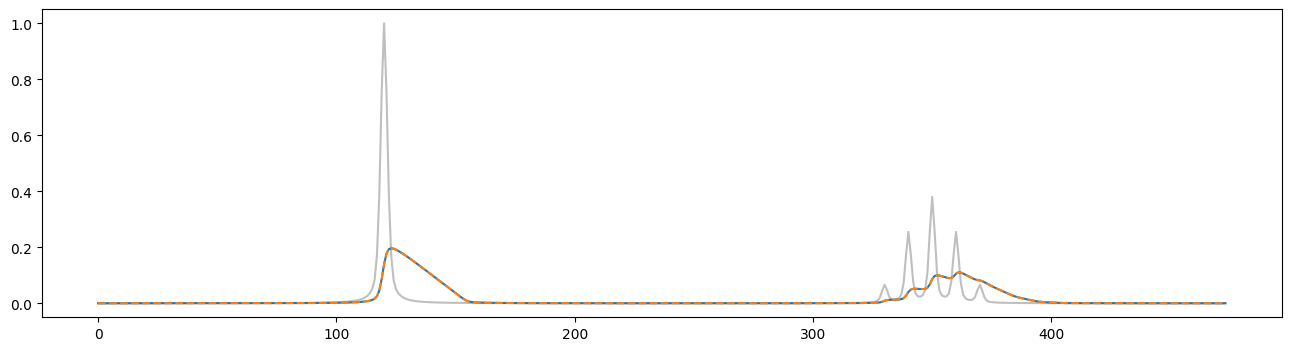

In [38]:
response_function = resp.reshape(1, 1, -1)
distorted_spectrum = distorted[0]
response_function_estimate_length = 71 # long: 91, exact: 71, short: 51

response_function_estimate, loss = fit_kernel(original_spectrum, distorted_spectrum, kernel_size=response_function_estimate_length, verbose=False)

plt.plot(response_function[0,0])
plt.plot(response_function_estimate[0,0], ls="--")
plt.title(f"Loss: {loss}")

spectrum_estimate = torch.conv1d(original_spectrum, response_function_estimate, padding='same')
plt.figure(figsize=(16,4))
plt.plot(original_spectrum[0,0], c="0.5", alpha=0.5)
plt.plot(distorted_spectrum[0])
plt.plot(spectrum_estimate[0,0], ls="--")


### Fitting with noise

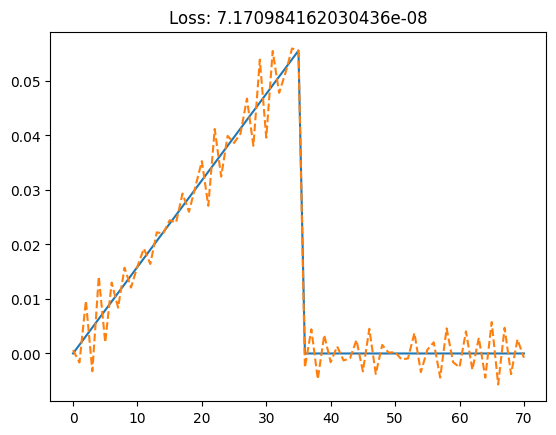

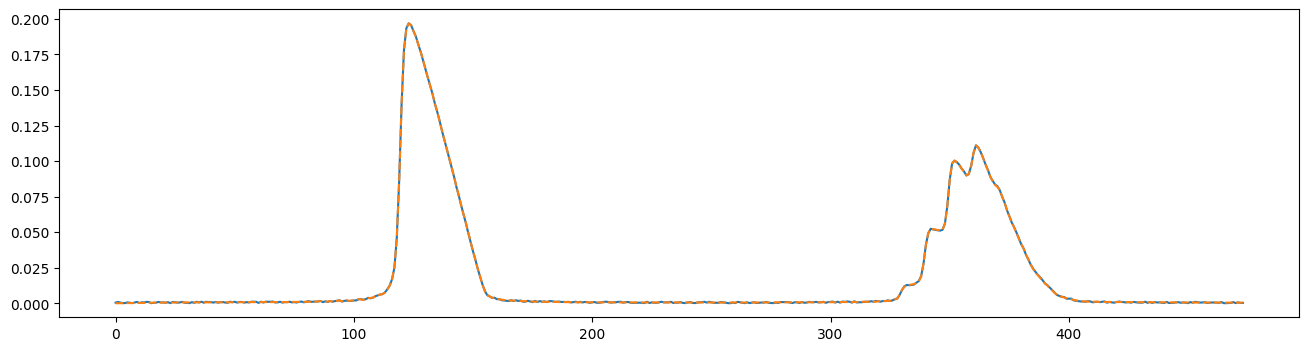

In [39]:
noise_level = 0.001 # small: 0.001, medium: 0.01
response_function_estimate_length = 71

response_function = resp.reshape(1, 1, -1)
distorted_spectrum_noised = distorted_spectrum + noise_level*torch.rand_like(distorted_spectrum)
original_spectrum_noised = original_spectrum + noise_level*torch.rand_like(original_spectrum)

response_function_estimate, loss = fit_kernel(original_spectrum_noised, distorted_spectrum_noised, kernel_size=response_function_estimate_length, verbose=False)

plt.plot(response_function[0,0])
plt.plot(response_function_estimate[0,0], ls="--")
plt.title(f"Loss: {loss}")

spectrum_estimate = torch.conv1d(original_spectrum_noised, response_function_estimate, padding='same')
plt.figure(figsize=(16,4))
plt.plot(distorted_spectrum_noised[0,0], c="0.5", alpha=0.5)
plt.plot(distorted_spectrum_noised[0])
plt.plot(spectrum_estimate[0,0], ls="--")

### Fitting on part of the spectrum

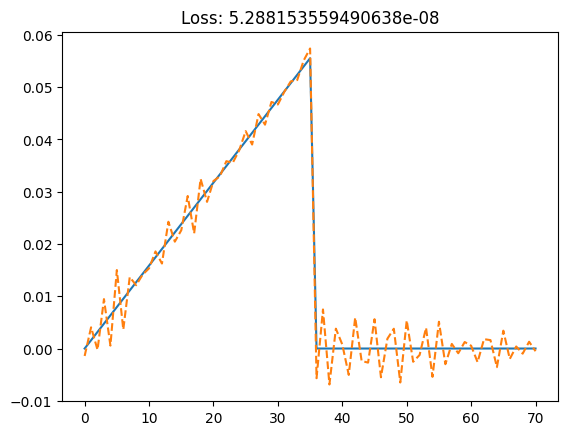

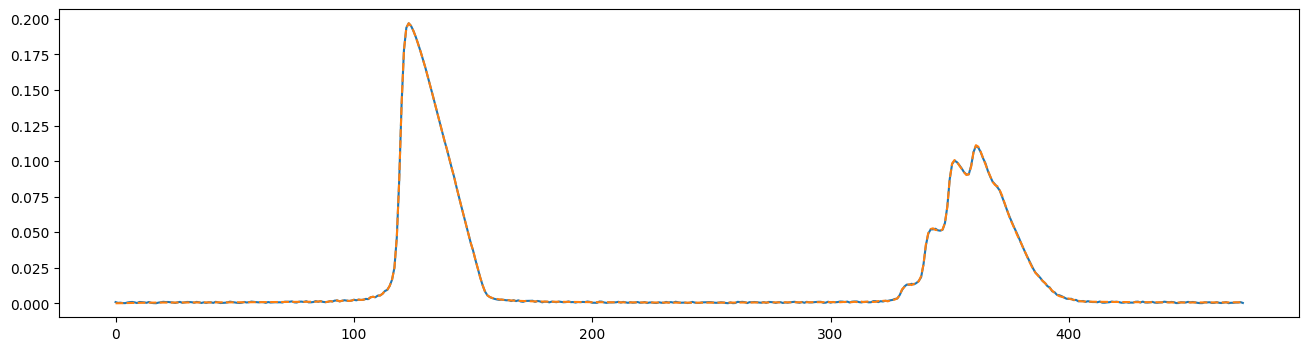

In [47]:
noise_level = 0.001 # small: 0.001, medium: 0.01
response_function_estimate_length = 71
fitting_range = (50, 190) # singlet: (50, 190), multiplet: (300, 450)

response_function = resp.reshape(1, 1, -1)
distorted_spectrum_noised = distorted_spectrum + noise_level*torch.rand_like(distorted_spectrum)
original_spectrum_noised = original_spectrum + noise_level*torch.rand_like(original_spectrum)

response_function_estimate, loss = fit_kernel(original_spectrum_noised[:,:,fitting_range[0]:fitting_range[1]], distorted_spectrum_noised[:,fitting_range[0]:fitting_range[1]], kernel_size=response_function_estimate_length, verbose=False)

plt.plot(response_function[0,0])
plt.plot(response_function_estimate[0,0], ls="--")
plt.title(f"Loss: {loss}")

spectrum_estimate = torch.conv1d(original_spectrum_noised, response_function_estimate, padding='same')
plt.figure(figsize=(16,4))
plt.plot(distorted_spectrum_noised[0,0], c="0.5", alpha=0.5)
plt.plot(distorted_spectrum_noised[0])
plt.plot(spectrum_estimate[0,0], ls="--")

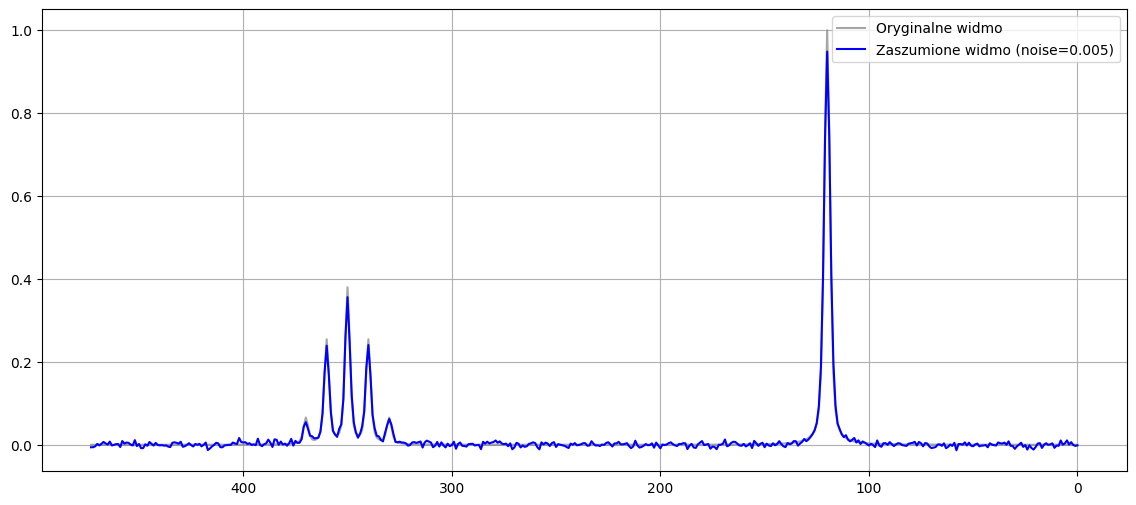

In [ ]:
df = pd.read_csv(file_path, header=None)
df.columns = ["intensity"]
df["index"] = range(1, len(df) + 1)

original_spectrum = torch.tensor(df["intensity"].values, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

def gaussian_kernel(size: int, sigma: float):
    x = torch.arange(size) - size // 2
    g = torch.exp(-x**2 / (2*sigma**2))
    return g / g.sum()

response_function_length = 21
#######funkcja odp musi być nieparzysta######
gaussian_response_function = gaussian_kernel(response_function_length, sigma=0.5)
#
response_function = gaussian_response_function.reshape(1, 1, -1)

def make_distorted_spectrum(original_spectrum, response_function, noise_level=0.001):
    distorted = F.conv1d(original_spectrum, response_function, padding=response_function.shape[-1]//2)
    distorted = distorted + noise_level * original_spectrum.max() * torch.randn_like(original_spectrum)
    return distorted

noise_level = 0.005
#change noise_level from 0.005 to 0.04
distorted_spectrum = make_distorted_spectrum(original_spectrum, response_function, noise_level=noise_level)

plt.figure(figsize=(14,6))
plt.plot(original_spectrum[0,0], label="Oryginalne widmo", c="0.5", alpha=0.7)
plt.plot(distorted_spectrum[0,0], label=f"Zaszumione widmo (noise={noise_level})", c="blue")
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
response_function = triangle_response_function.reshape(1, 1, -1)
distorted_spectrum = torch.nn.functional.conv1d(original_spectrum, response_function, padding=response_function_length//2)

response_function_estimate, loss = fit_kernel(original_spectrum, distorted_spectrum, kernel_size=61, verbose=False, steps=12_000)

plt.plot(np.arange(-response_function.shape[-1]//2, response_function.shape[-1]//2), response_function[0,0])
plt.plot(np.arange(-response_function_estimate.shape[-1]//2, response_function_estimate.shape[-1]//2), response_function_estimate[0,0], ls="--")
plt.title(f"Loss: {loss}")

spectrum_estimate = torch.conv1d(original_spectrum, response_function_estimate, padding='same')
plt.figure(figsize=(16,4))
plt.plot(original_spectrum[0], c="0.5", alpha=0.5)
plt.plot(distorted_spectrum[0])
plt.plot(spectrum_estimate[0], ls="--")

## Shim Coil Response Function (SCRF) extraction

Optimal spectrum extracted to ./deconvolved_data/opti_spectrum.npy
Extracting spectra from fids...


100%|██████████| 41/41 [00:52<00:00,  1.29s/it]


Spectra extracted to ./deconvolved_data/scrf_workshop.npy

Extracting SCRFs...


100%|██████████| 41/41 [01:43<00:00,  2.52s/it]


SCRFs extracted to ./deconvolved_data/scrf_workshop.pt, losses saved to ./deconvolved_data/losses_scrf_workshop.pt
[INFO] Załadowano SCRFs: shape=(41, 61)
[INFO] Załadowano widma: shape=(41, 257)


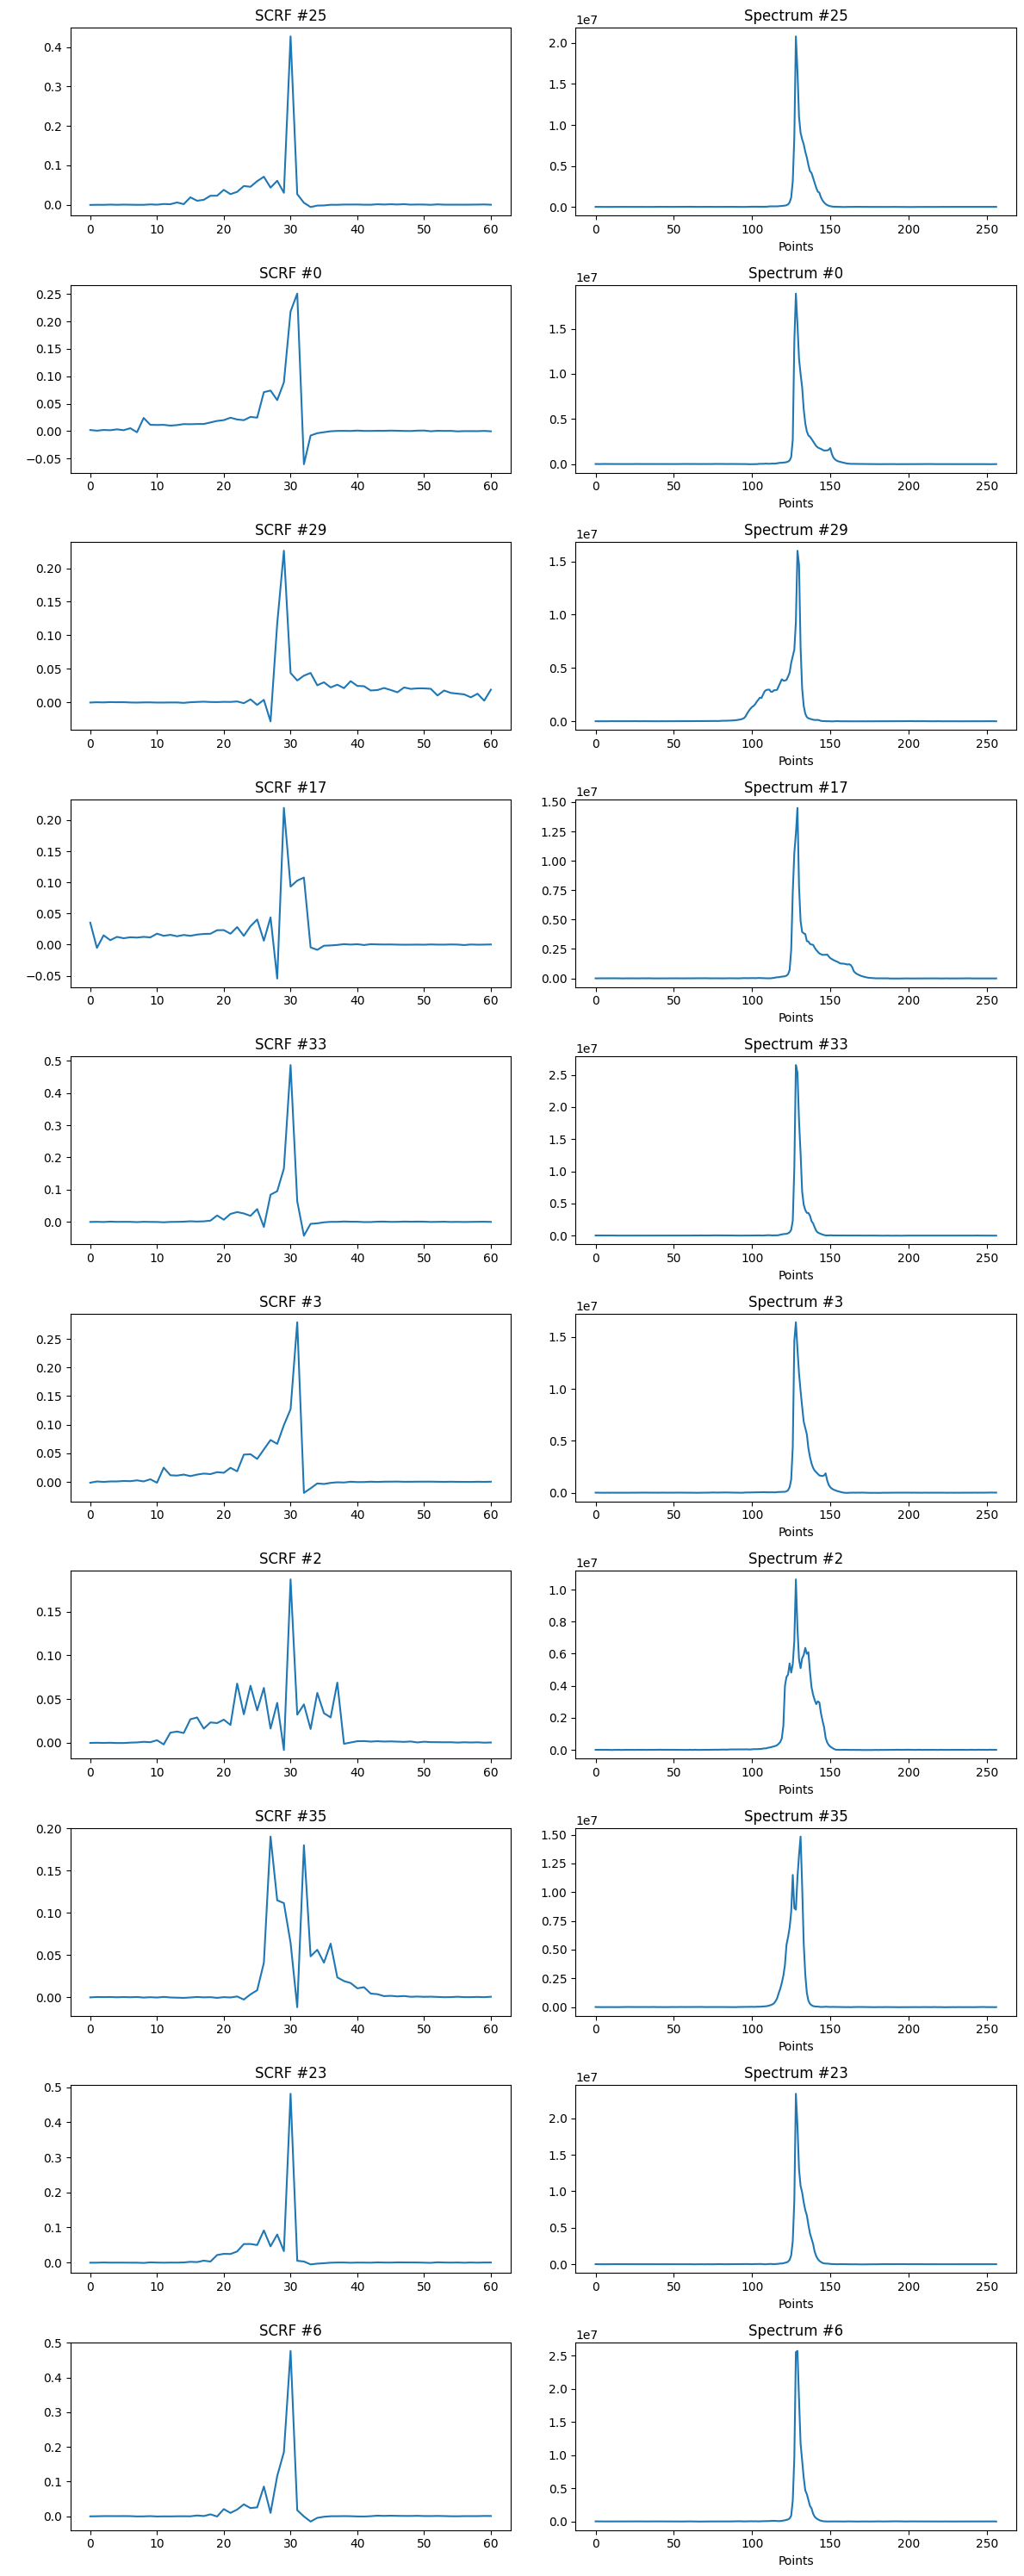

In [ ]:
#2min45s
#!pip install nmrglue
from extract_scrf_from_fids1 import run
import os

data_dir = "./SCRF_extraction"
opti_fid_path = "./OPTI_INPUT_SPECTRA/shimmed_lineshape.fid"

# output
spectra_file = "./deconvolved_data/scrf_workshop.npy"
spectra_file_names = "./deconvolved_data/scrf_workshop_names.csv"
opi_spectrum_file = "./deconvolved_data/opti_spectrum.npy"
responses_file = "./deconvolved_data/scrf_workshop.pt"
losses_file = "./deconvolved_data/losses_scrf_workshop.pt"

os.environ["DATA_DIR"] = data_dir
os.environ["OPTI_FID_PATH"] = opti_fid_path
os.environ["SPECTRA_FILE"] = spectra_file
os.environ["SPECTRA_FILE_NAMES"] = spectra_file_names
os.environ["OPI_SPECTRUM_FILE"] = opi_spectrum_file
os.environ["RESPONSES_FILE"] = responses_file
os.environ["LOSSES_FILE"] = losses_file

#!python extract_scrf_from_fids1.py
run()